In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_fscore_support
import joblib
import xgboost as xgb

RND = 42
np.random.seed(RND)
random.seed(RND)


In [2]:

df = pd.read_csv("data/parkinsons.data")  # change path if needed


df.head(), df.shape


(             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
 0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
 1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
 2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
 3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
 4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   
 
    MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
 0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
 1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
 2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
 3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
 4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   
 
    Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  

# EDA

In [3]:

# basic info
print(df.columns.tolist())
df['status'].value_counts()


['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


status
1    147
0     48
Name: count, dtype: int64

In [4]:
# Describe
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


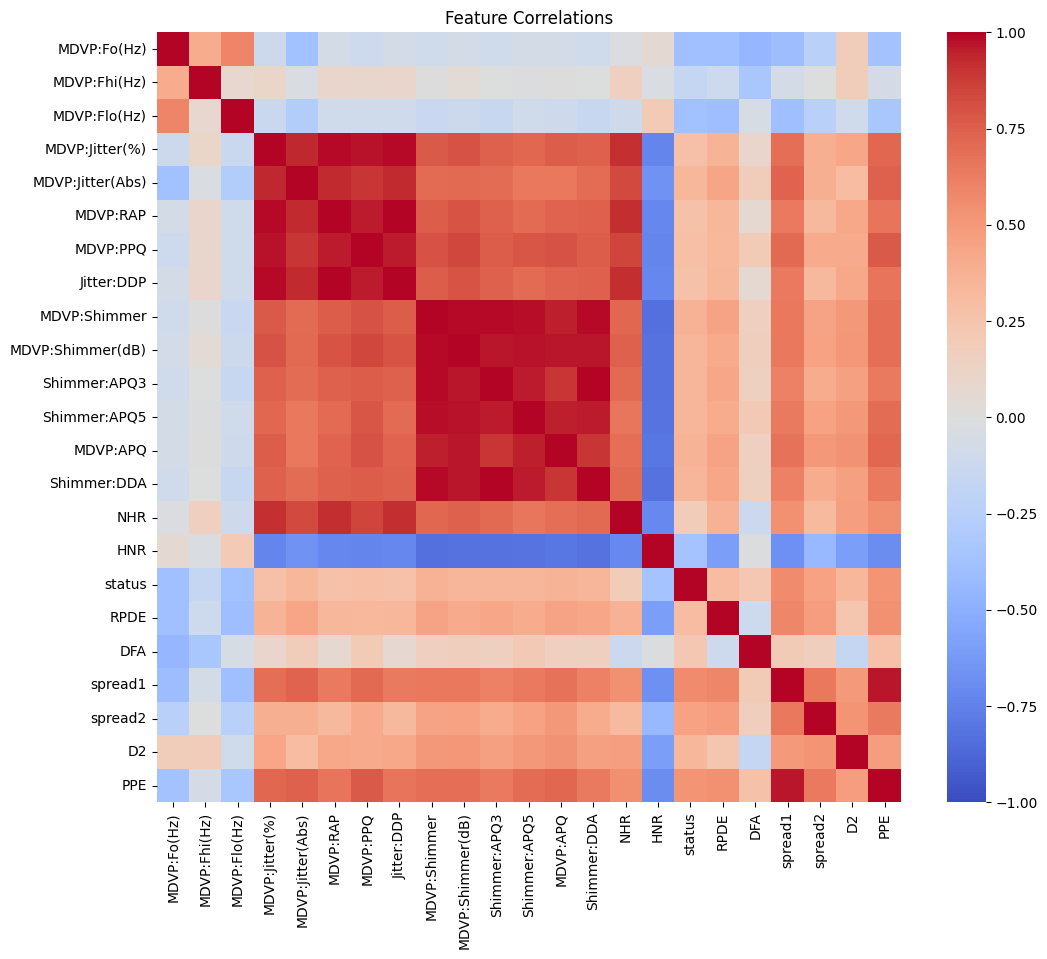

In [5]:

# Correlation heatmap (drop name)
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['name']).corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlations')
plt.show()

# Prepare X, y and split

In [6]:
# drop identifier
X = df.drop(columns=['name', 'status'])
y = df['status']

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RND)

print(X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts())

(156, 22) (39, 22) status
1    118
0     38
Name: count, dtype: int64 status
1    29
0    10
Name: count, dtype: int64


In [14]:
feature_columns = X.columns.tolist()
pd.Series(feature_columns).to_csv("feature_columns.csv", index=False, header=False)
print("✅ Saved feature list to feature_columns.csv")


✅ Saved feature list to feature_columns.csv


# Pipeline and baseline model (RandomForest)

In [7]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RND, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)
y_pred = pipe_rf.predict(X_test)
y_proba = pipe_rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


Accuracy: 0.9230769230769231
ROC AUC: 0.9620689655172414
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



# Cross-validation & other models quickly

In [8]:
# Cross-val for RF, SVM, XGBoost
models = {
    'RandomForest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=RND, n_jobs=-1))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=RND))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()), ('clf', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RND))])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name}: ROC AUC CV mean {scores.mean():.4f} (+/- {scores.std():.4f})")


RandomForest: ROC AUC CV mean 0.9539 (+/- 0.0201)
SVM: ROC AUC CV mean 0.8910 (+/- 0.0453)
XGBoost: ROC AUC CV mean 0.9640 (+/- 0.0091)


# GridSearch example (RandomForest)

In [9]:
param_grid = {
    'clf__n_estimators': [100, 200, 400],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}

gs = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=RND))]),
                  param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)

gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
best_rf = gs.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test ROC AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
Test ROC AUC: 0.9724137931034483


# Evaluate and plot ROC + confusion matrix

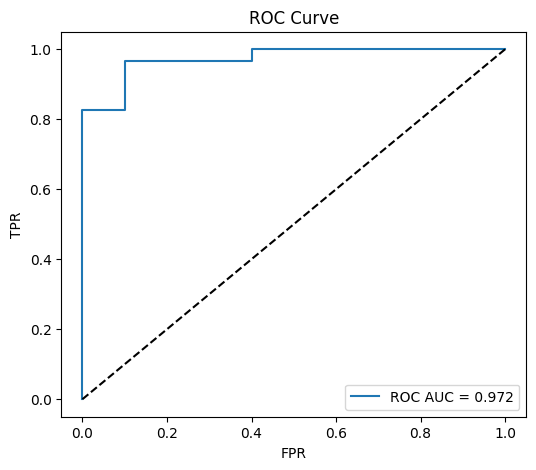

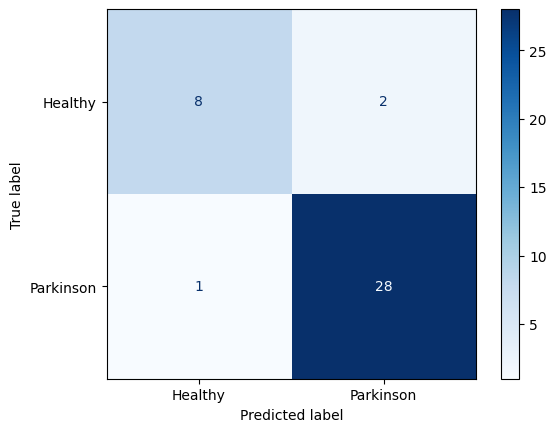

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

y_proba = best_rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()
plt.show()

# confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, best_rf.predict(X_test)), display_labels=['Healthy','Parkinson'])
disp.plot(cmap='Blues')
plt.show()


# Feature importance + SHAP (explainability)

PPE               0.138620
spread1           0.104656
MDVP:Fo(Hz)       0.070832
NHR               0.061216
MDVP:RAP          0.053748
MDVP:Fhi(Hz)      0.049719
Jitter:DDP        0.048968
MDVP:Flo(Hz)      0.048202
MDVP:APQ          0.038891
spread2           0.038776
Shimmer:APQ5      0.037378
D2                0.036059
RPDE              0.030696
Shimmer:APQ3      0.030390
MDVP:Jitter(%)    0.027795
Shimmer:DDA       0.027046
MDVP:PPQ          0.026854
HNR               0.026835
MDVP:Shimmer      0.026815
DFA               0.026250
dtype: float64


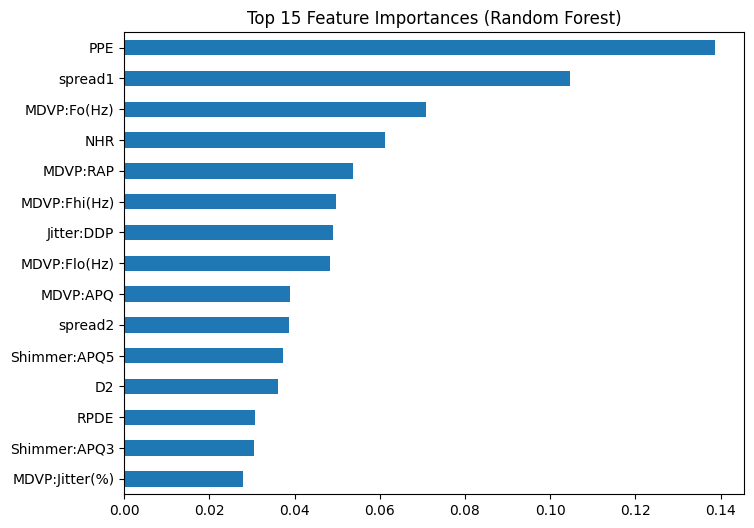

In [11]:
# Feature importance from RF
importances = best_rf.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feat_imp.head(20))

# Plot top features
plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()


# SHAP (install shap for heavy lifting). Use TreeExplainer for tree models.

c:\Users\lenovo\Desktop\Parkinson’s\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lenovo\AppData\Local\Temp\ipykernel_19968\2384669775.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=X.columns)
c:\Users\lenovo\Desktop\Parkinson’s\venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\lenovo\Desktop\Parkinson’s\venv\Lib\s

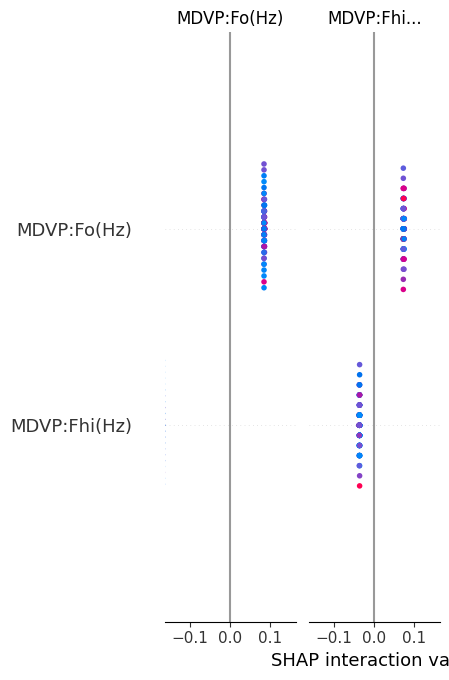

In [12]:
import shap
explainer = shap.TreeExplainer(best_rf.named_steps['clf'])
# Use a subset for speed
X_sample = X_train.sample(n=min(100, len(X_train)), random_state=RND)
shap_values = explainer.shap_values(X_sample)
# summary plot
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)


# Save model + scaler (export)

In [13]:
# Save the entire pipeline
joblib.dump(best_rf, "best_parkinsons_pipeline.pkl")
# To load later:
# loaded = joblib.load("best_parkinsons_pipeline.pkl")


['best_parkinsons_pipeline.pkl']